In [1]:
import torch

In [2]:
act_w = torch.load("prepares/Llama-2-7b-hf_activation_weight.pt", map_location="cpu", weights_only=False)

In [4]:
for name, w in act_w.items():
    print(name, w.shape)

model.layers.0.self_attn.q_proj torch.Size([4096])
model.layers.0.self_attn.k_proj torch.Size([4096])
model.layers.0.self_attn.v_proj torch.Size([4096])
model.layers.0.self_attn.o_proj torch.Size([4096])
model.layers.0.mlp.gate_proj torch.Size([4096])
model.layers.0.mlp.up_proj torch.Size([4096])
model.layers.0.mlp.down_proj torch.Size([11008])
model.layers.1.self_attn.q_proj torch.Size([4096])
model.layers.1.self_attn.k_proj torch.Size([4096])
model.layers.1.self_attn.v_proj torch.Size([4096])
model.layers.1.self_attn.o_proj torch.Size([4096])
model.layers.1.mlp.gate_proj torch.Size([4096])
model.layers.1.mlp.up_proj torch.Size([4096])
model.layers.1.mlp.down_proj torch.Size([11008])
model.layers.2.self_attn.q_proj torch.Size([4096])
model.layers.2.self_attn.k_proj torch.Size([4096])
model.layers.2.self_attn.v_proj torch.Size([4096])
model.layers.2.self_attn.o_proj torch.Size([4096])
model.layers.2.mlp.gate_proj torch.Size([4096])
model.layers.2.mlp.up_proj torch.Size([4096])
model.la

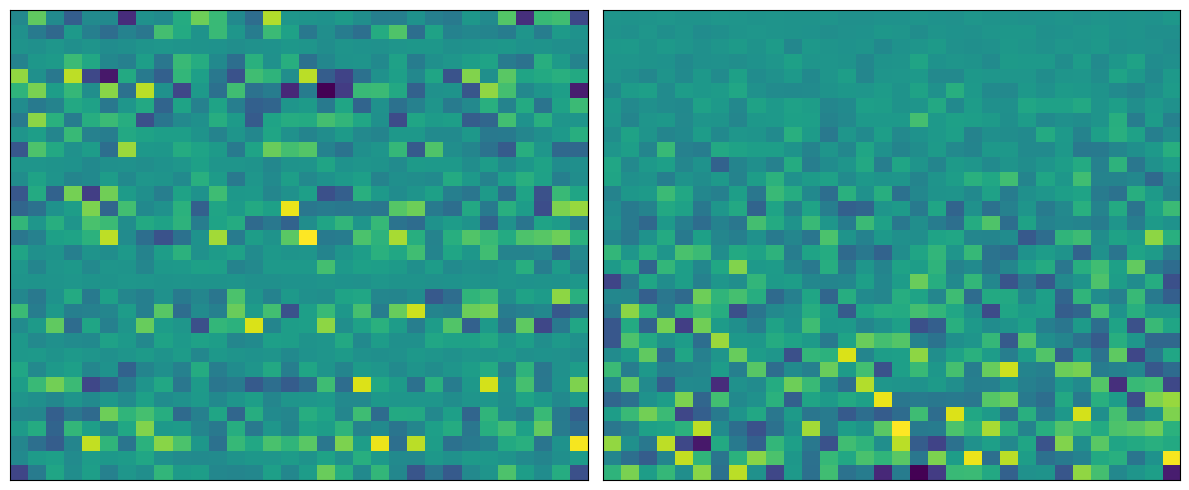

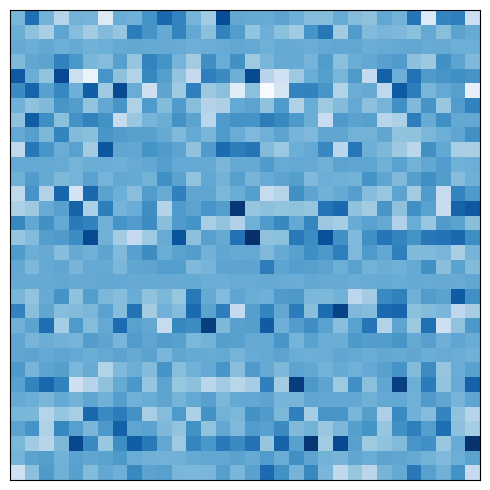

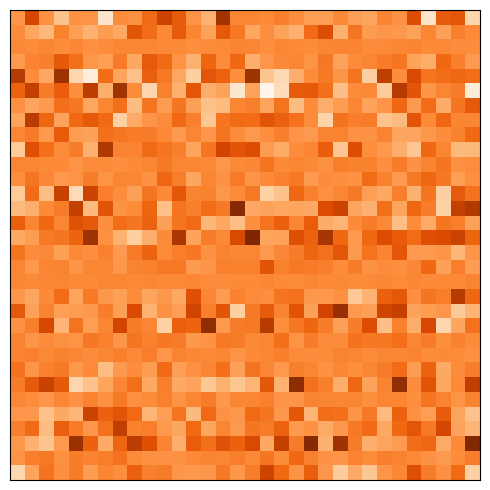

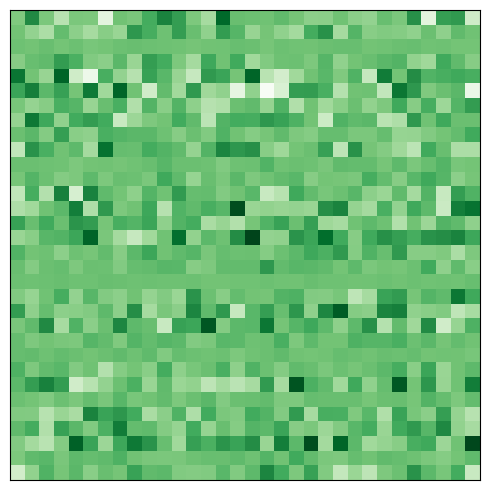

First 5 row norms before sort: [ 8.67510887  5.47726367  0.62133899  4.51678214 10.57277715]
First 5 row norms after sort : [0.33275189 0.62133899 1.01780657 1.41314343 1.58452877]


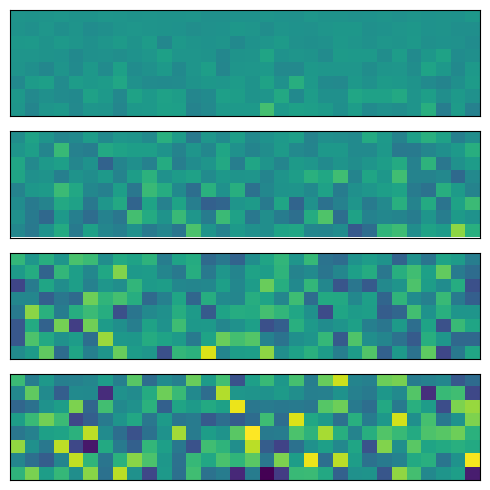

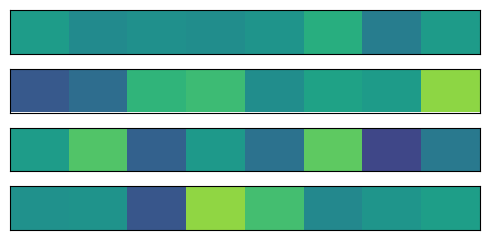

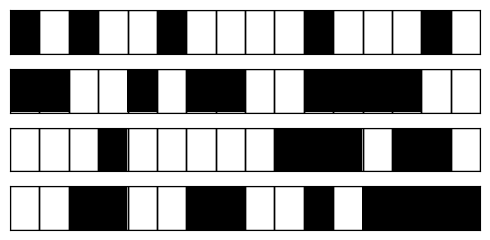

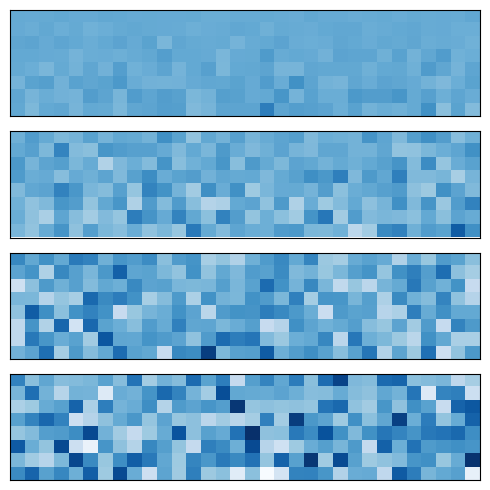

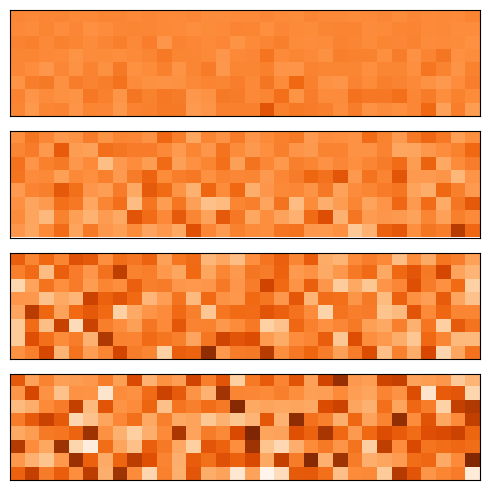

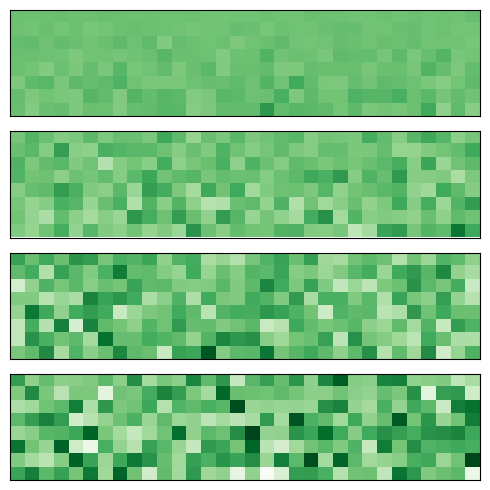

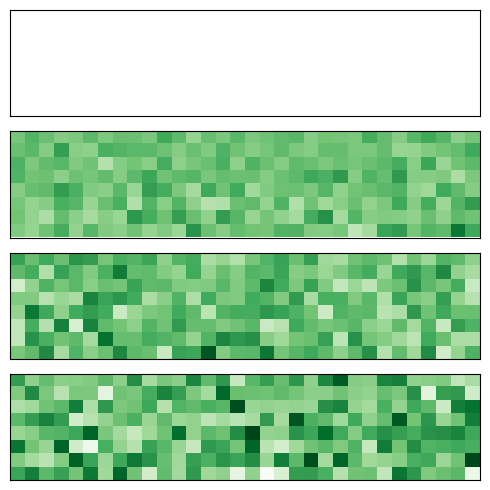

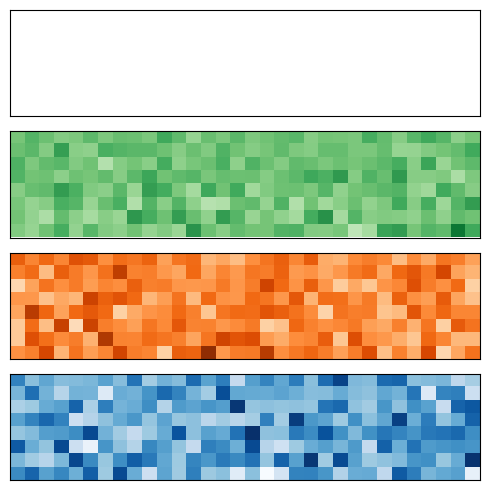

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 生成 32x32 随机矩阵
np.random.seed(42)
A = np.random.randn(32, 32)
a = np.array(list(range(1, 33))) / 16.
A= A*a[:, np.newaxis]  # 按行缩放矩阵
# 随机打乱A的行排序
np.random.shuffle(A)


# 计算每一行的 2 范数并按升序排序
row_norms = np.linalg.norm(A, ord=2, axis=1)
sorted_idx = np.argsort(row_norms)
A_sorted = A[sorted_idx]

# 可视化排序前后矩阵
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(A, aspect='auto', cmap='viridis')
# axes[0].set_title('Before sorting')
# axes[0].set_xlabel('Column index')
# axes[0].set_ylabel('Row index')
axes[0].set_yticks([])
axes[0].set_xticks([])
# plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(A_sorted, aspect='auto', cmap='viridis')
# axes[1].set_title('After sorting by row L2 norm')
# axes[1].set_xlabel('Column index')
# axes[1].set_ylabel('Sorted row index')
axes[1].set_yticks([])
axes[1].set_xticks([])
# plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 1, figsize=(5, 5))
im0 = axes.imshow(A, aspect='auto', cmap='Blues')
# axes[0].set_title('Before sorting')
# axes[0].set_xlabel('Column index')
# axes[0].set_ylabel('Row index')
axes.set_yticks([])
axes.set_xticks([])
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
im0 = axes.imshow(A, aspect='auto', cmap='Oranges')
# axes[0].set_title('Before sorting')
# axes[0].set_xlabel('Column index')
# axes[0].set_ylabel('Row index')
axes.set_yticks([])
axes.set_xticks([])
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
im0 = axes.imshow(A, aspect='auto', cmap='Greens')
# axes[0].set_title('Before sorting')
# axes[0].set_xlabel('Column index')
# axes[0].set_ylabel('Row index')
axes.set_yticks([])
axes.set_xticks([])
plt.tight_layout()
plt.show()

print('First 5 row norms before sort:', row_norms[:5])
print('First 5 row norms after sort :', np.linalg.norm(A_sorted, ord=2, axis=1)[:5])
# 把A_sorted按行分成4份，每份8行，imshow每份的热力图，标题分别是第1-8行、第9-16行、第17-24行、第25-32行的行L2范数平均值。每个子图都不显示坐标轴刻度。
vmin, vmax = A_sorted.min(), A_sorted.max()
fig, axes = plt.subplots(4, 1, figsize=(5, 5))
for i in range(4):
    start = i * 8
    end = (i + 1) * 8
    sub_matrix = A_sorted[start:end]
    im = axes[i].imshow(sub_matrix, aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    # axes[i].set_title(f'Rows {start+1}-{end}: avg L2 norm = {np.mean(np.linalg.norm(sub_matrix, ord=2, axis=1)):.2f}')
    axes[i].set_yticks([])
    axes[i].set_xticks([])
# 所有子图的colorbar的范围设置为A_sorted的最小值和最大值
# plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, ticks=np.linspace(vmin, vmax, num=5))
plt.tight_layout()
plt.show()
# 取每个sub_matrix的前8个元素，绘制成四个向量的热力图，。
fig, axes = plt.subplots(4, 1, figsize=(5, 2.5))
for i in range(4):
    start = i * 8
    end = (i + 1) * 8
    sub_matrix = A_sorted[start:end]
    vector = sub_matrix[-1, -9:-1] 
    im = axes[i].imshow(vector.reshape(1, -1), aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[i].set_yticks([])
    axes[i].set_xticks([])
plt.tight_layout()
plt.show()
# 16个0/1组成的随机向量，imshow成黑白热力图.
# 划分每个格子的框线，边框线宽为1，边框线颜色为黑色。
random_vectors = np.random.randint(0, 2, size=(4, 16))
fig, axes = plt.subplots(4, 1, figsize=(5, 2.5))
for i in range(4):
    vector = random_vectors[i]
    im = axes[i].imshow(vector.reshape(1, -1), aspect='auto', cmap='gray', vmin=0, vmax=1)
    axes[i].set_yticks([])
    axes[i].set_xticks([])
    # 划分每个格子的框线，边框线宽为1，边框线颜色为黑色。
    for j in range(16):
        axes[i].add_patch(plt.Rectangle((j-0.5, -0.5), 1, 1, fill=False, edgecolor='black', linewidth=1))
plt.tight_layout()
plt.show()

# 把A_sorted按行分成4份，每份8行，imshow每份的热力图，标题分别是第1-8行、第9-16行、第17-24行、第25-32行的行L2范数平均值。每个子图都不显示坐标轴刻度。
# 浅蓝色到深蓝色的渐变色，vmin和vmax分别是A_sorted的最小值和最大值。
vmin, vmax = A_sorted.min(), A_sorted.max()
fig, axes = plt.subplots(4, 1, figsize=(5, 5))
for i in range(4):
    start = i * 8
    end = (i + 1) * 8
    sub_matrix = A_sorted[start:end]
    im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Blues', vmin=vmin, vmax=vmax)
    # axes[i].set_title(f'Rows {start+1}-{end}: avg L2 norm = {np.mean(np.linalg.norm(sub_matrix, ord=2, axis=1)):.2f}')
    axes[i].set_yticks([])
    axes[i].set_xticks([])
# 所有子图的colorbar的范围设置为A_sorted的最小值和最大值
# plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, ticks=np.linspace(vmin, vmax, num=5))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(5, 5))
for i in range(4):
    start = i * 8
    end = (i + 1) * 8
    sub_matrix = A_sorted[start:end]
    im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Oranges', vmin=vmin, vmax=vmax)
    # axes[i].set_title(f'Rows {start+1}-{end}: avg L2 norm = {np.mean(np.linalg.norm(sub_matrix, ord=2, axis=1)):.2f}')
    axes[i].set_yticks([])
    axes[i].set_xticks([])
# 所有子图的colorbar的范围设置为A_sorted的最小值和最大值
# plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, ticks=np.linspace(vmin, vmax, num=5))
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(4, 1, figsize=(5, 5))
for i in range(4):
    start = i * 8
    end = (i + 1) * 8
    sub_matrix = A_sorted[start:end]
    im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Greens', vmin=vmin, vmax=vmax)
    # axes[i].set_title(f'Rows {start+1}-{end}: avg L2 norm = {np.mean(np.linalg.norm(sub_matrix, ord=2, axis=1)):.2f}')
    axes[i].set_yticks([])
    axes[i].set_xticks([])
# 所有子图的colorbar的范围设置为A_sorted的最小值和最大值
# plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, ticks=np.linspace(vmin, vmax, num=5))
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(4, 1, figsize=(5, 5))
for i in range(4):
    start = i * 8
    end = (i + 1) * 8
    sub_matrix = A_sorted[start:end]
    if i == 0:
        sub_matrix = np.zeros_like(sub_matrix)  # 第一份全为0
        im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Greys', vmin=0, vmax=vmax)
        
    else:
        im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Greens', vmin=vmin, vmax=vmax)
    # axes[i].set_title(f'Rows {start+1}-{end}: avg L2 norm = {np.mean(np.linalg.norm(sub_matrix, ord=2, axis=1)):.2f}')
    axes[i].set_yticks([])
    axes[i].set_xticks([])
# 所有子图的colorbar的范围设置为A_sorted的最小值和最大值
# plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, ticks=np.linspace(vmin, vmax, num=5))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(5, 5))
for i in range(4):
    start = i * 8
    end = (i + 1) * 8
    sub_matrix = A_sorted[start:end]
    if i == 0:
        sub_matrix = np.zeros_like(sub_matrix)  # 第一份全为0
        im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Greys', vmin=0, vmax=vmax)
        
    elif i == 1:
        im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Greens', vmin=vmin, vmax=vmax)
    elif i == 2:
        im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Oranges', vmin=vmin, vmax=vmax)
    else:
        im = axes[i].imshow(sub_matrix, aspect='auto', cmap='Blues', vmin=vmin, vmax=vmax)
    # axes[i].set_title(f'Rows {start+1}-{end}: avg L2 norm = {np.mean(np.linalg.norm(sub_matrix, ord=2, axis=1)):.2f}')
    axes[i].set_yticks([])
    axes[i].set_xticks([])
# 所有子图的colorbar的范围设置为A_sorted的最小值和最大值
# plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, ticks=np.linspace(vmin, vmax, num=5))
plt.tight_layout()
plt.show()

In [8]:

s = 32
mlp_de_num = 64
de = (16*s+32**2+8*s)*16
mlp = 11008*4096
mlp_avg = de*mlp_de_num/mlp
print(mlp_avg)


attn_de_num = 8
attn = 4096**2
attn_avg = de*attn_de_num/attn
print(attn_avg)

avg = de*(mlp_de_num*5+attn_de_num*2)/(mlp*3+attn*4)
print(avg)


0.040697674418604654
0.013671875
0.047603626943005184
